# Funciones continuas y discretas

**Módulo II — Introducción a la simulación de eventos discretos**

Este notebook explica de forma sencilla la diferencia entre valores discretos y continuos, cómo se representan mediante funciones y qué relación tienen con la simulación.

## Resultados de aprendizaje

- Reconocer variables discretas y continuas.
- Interpretar tablas y gráficas de funciones discretas y continuas.
- Diferenciar un cambio gradual de un cambio producido por eventos.
- Relacionar estos conceptos con ejemplos de simulación.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. ¿Qué significa discreto?

Una cantidad es **discreta** cuando solo puede tomar valores separados que normalmente pueden contarse.

Ejemplos:

- número de clientes en una fila: 0, 1, 2, 3, ...;
- número de máquinas dañadas;
- cantidad de pedidos recibidos;
- número obtenido al lanzar un dado.

No tiene sentido afirmar que hay 2,5 clientes en una fila. Se puede pasar de 2 a 3 cuando llega una persona, pero no existen todos los valores intermedios.

> **Idea:** discreto significa separado, contable o producido mediante saltos.

In [3]:
numero_pedidos = np.arange(0, 8)
probabilidad = np.array([0.05, 0.10, 0.18, 0.25, 0.20, 0.12, 0.07, 0.03])

tabla_discreta = pd.DataFrame({
    'Número de pedidos': numero_pedidos,
    'Probabilidad': probabilidad,
})
tabla_discreta

,Número de pedidos,Probabilidad
0,0,0.05
1,1,0.10
2,2,0.18
3,3,0.25
4,4,0.20
5,5,0.12
6,6,0.07
7,7,0.03


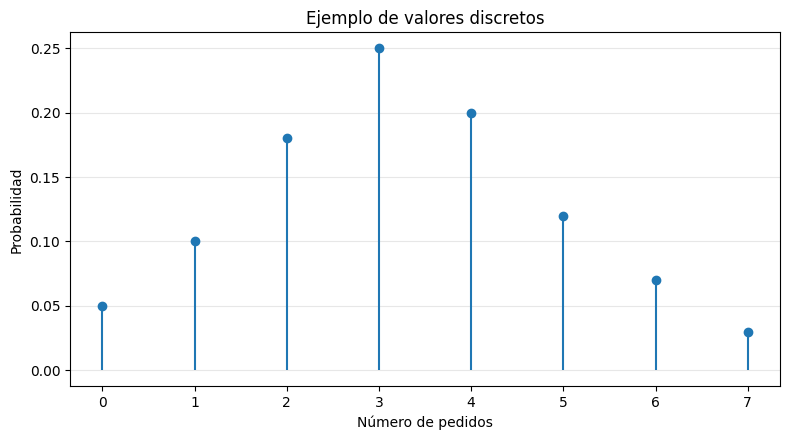

In [4]:
plt.figure(figsize=(8, 4.5))
plt.stem(numero_pedidos, probabilidad, basefmt=' ')
plt.xlabel('Número de pedidos')
plt.ylabel('Probabilidad')
plt.title('Ejemplo de valores discretos')
plt.xticks(numero_pedidos)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### ¿Cómo se interpreta la gráfica discreta?

Cada punto representa una posibilidad separada: cero pedidos, un pedido, dos pedidos y así sucesivamente. Los puntos no se unen porque valores como 2,4 pedidos no pertenecen al conjunto de resultados posibles.

## 2. ¿Qué significa continuo?

Una cantidad es **continua** cuando puede tomar cualquier valor dentro de un intervalo, incluidos valores decimales. Generalmente se obtiene mediante una medición.

Ejemplos:

- tiempo de atención: 4,2 minutos;
- temperatura: 23,56 °C;
- peso de un producto: 1,037 kg;
- nivel de líquido en un tanque;
- distancia recorrida por un vehículo.

Entre 20 °C y 21 °C pueden existir 20,1; 20,25; 20,999 y muchos otros valores.

> **Idea:** continuo significa medible y capaz de tomar valores intermedios.

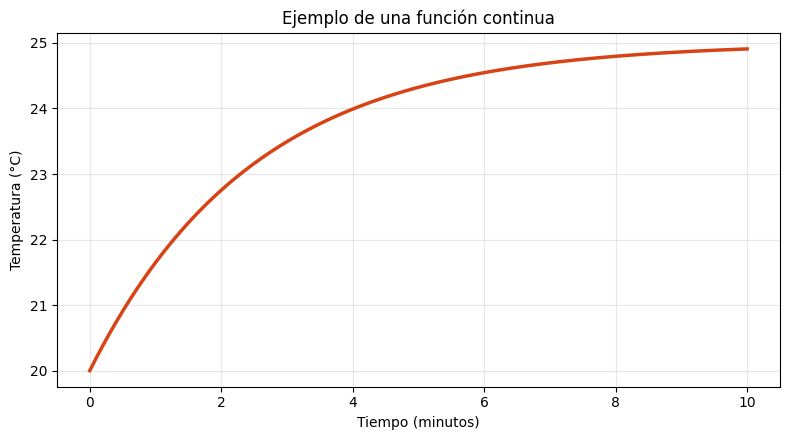

In [5]:
tiempo = np.linspace(0, 10, 300)
temperatura = 20 + 5*(1 - np.exp(-0.4*tiempo))

plt.figure(figsize=(8, 4.5))
plt.plot(tiempo, temperatura, linewidth=2.5, color='#D84315')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Temperatura (°C)')
plt.title('Ejemplo de una función continua')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ¿Cómo se interpreta la gráfica continua?

La línea muestra que la temperatura cambia gradualmente con el tiempo. En el modelo se puede calcular un valor para cualquier instante, por ejemplo 2,5 o 7,83 minutos. La gráfica puede dibujarse sin levantar el lápiz porque no presenta saltos.

## 3. Función discreta y función continua

Una **función discreta** se evalúa en entradas separadas. Una **función continua** se puede evaluar en todos los valores de un intervalo.

| Característica | Discreta | Continua |
|---|---|---|
| Valores | Separados y contables | Cualquier valor de un intervalo |
| Origen habitual | Conteo | Medición |
| Gráfica | Puntos, barras o escalones | Línea o curva sin interrupciones |
| Ejemplo | Número de clientes | Tiempo de espera |
| Decimales | Generalmente no aplican al conteo | Son posibles |

### Dos ejemplos matemáticos

Función discreta, definida solamente para $n=0,1,2,3,\ldots$:

$$f(n)=2n+1.$$

Función continua, definida para cualquier número real $x$:

$$g(x)=2x+1.$$

Aunque las fórmulas son iguales, el tipo de función cambia por los valores que puede tomar la entrada.

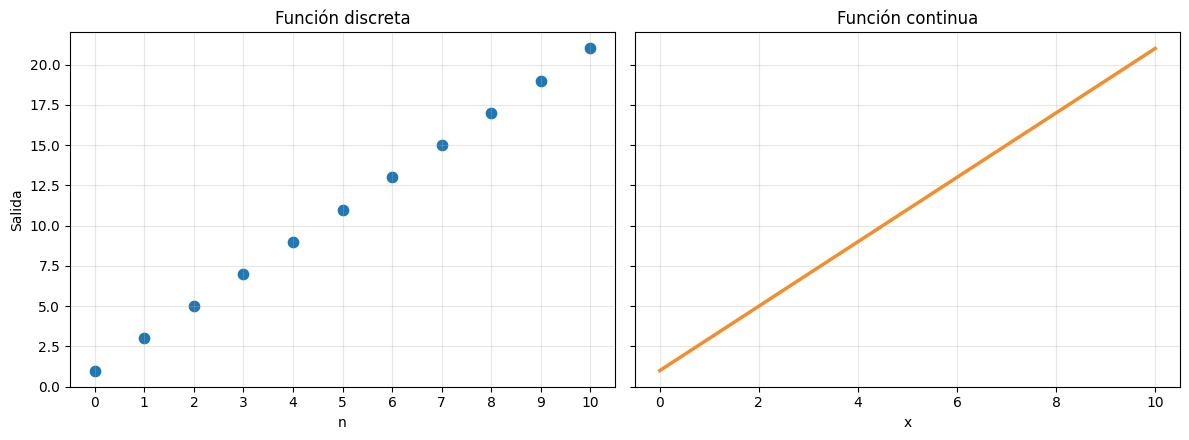

In [6]:
n = np.arange(0, 11)
f_n = 2*n + 1
x = np.linspace(0, 10, 300)
g_x = 2*x + 1

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ejes[0].scatter(n, f_n, s=55)
ejes[0].set(title='Función discreta', xlabel='n', ylabel='Salida')
ejes[0].set_xticks(n)
ejes[0].grid(alpha=0.3)

ejes[1].plot(x, g_x, linewidth=2.5, color='#F28E2B')
ejes[1].set(title='Función continua', xlabel='x')
ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Cambios discretos en una simulación

En una simulación de eventos discretos, el estado del sistema cambia cuando ocurre un evento.

Ejemplo de una fila:

- llega un cliente: la fila aumenta en uno;
- inicia una atención: la fila disminuye en uno;
- termina el servicio: se libera el servidor.

Entre dos eventos, el número de clientes puede permanecer igual. Por eso la evolución se representa como una función escalonada.

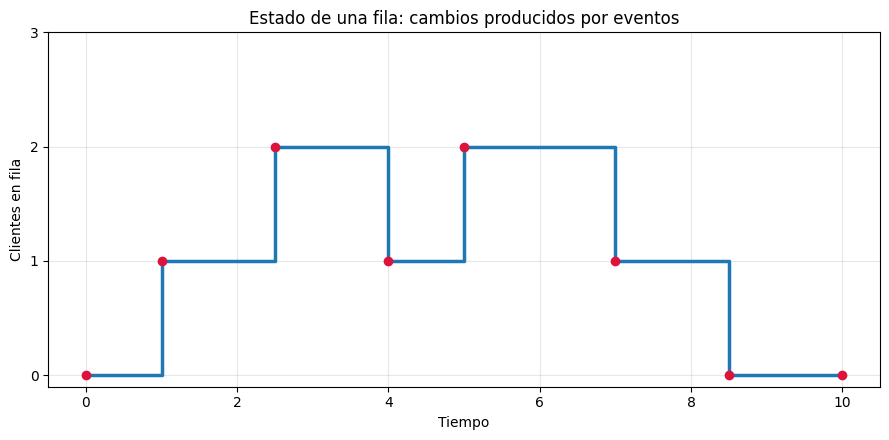

In [7]:
tiempos_eventos = np.array([0, 1, 2.5, 4, 5, 7, 8.5, 10])
clientes_en_fila = np.array([0, 1, 2, 1, 2, 1, 0, 0])

plt.figure(figsize=(9, 4.5))
plt.step(tiempos_eventos, clientes_en_fila, where='post', linewidth=2.5)
plt.scatter(tiempos_eventos, clientes_en_fila, color='crimson', zorder=3)
plt.xlabel('Tiempo')
plt.ylabel('Clientes en fila')
plt.title('Estado de una fila: cambios producidos por eventos')
plt.yticks(range(0, 4))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Un sistema puede combinar ambos tipos

Un mismo problema puede contener variables discretas y continuas.

En un restaurante:

- número de clientes: discreto;
- número de mesas ocupadas: discreto;
- tiempo de espera: continuo;
- duración de la preparación: continua;
- temperatura de los alimentos: continua.

El nombre **simulación de eventos discretos** no significa que todas sus variables sean discretas. Significa que el estado del modelo se actualiza principalmente cuando suceden eventos identificables, como llegadas, inicios o finalizaciones.

## 6. Variable aleatoria discreta y continua

En simulación también se utilizan variables aleatorias:

- Una variable aleatoria **discreta** asigna probabilidades a resultados contables, como el número de llegadas por hora. Ejemplos: Bernoulli, binomial y Poisson.
- Una variable aleatoria **continua** describe mediciones dentro de un intervalo, como el tiempo entre llegadas. Ejemplos: uniforme, normal y exponencial.

Para una variable discreta se habla de la probabilidad de un valor específico, por ejemplo $P(X=3)$. En una variable continua se trabaja normalmente con intervalos, por ejemplo $P(3<X<5)$, porque la probabilidad de un único valor exacto es cero.

## 7. Resumen

- **Discreto:** se cuenta, toma valores separados y suele cambiar mediante saltos.
- **Continuo:** se mide, puede tomar valores intermedios y suele representarse mediante una curva.
- La fórmula por sí sola no siempre determina el tipo; también importa el dominio de la variable.
- En simulación de eventos discretos, los cambios importantes ocurren cuando se presentan eventos.
- Un modelo puede combinar cantidades discretas y continuas.